In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [7]:
sns.get_dataset_names()
titanic = sns.load_dataset("titanic")
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

## Handle Missing Values


In [8]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_most = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_most.fit_transform(titanic[["embarked"]])
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Encoding


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic["embarked"])
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [13]:
X = titanic[features]
y = titanic[target]


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.head()

,pclass,sex,fare,embarked,age
331,1,1,28.5000,2,45.5
733,2,1,13.0000,2,23.0
382,3,1,7.9250,2,32.0
704,3,1,7.8542,2,26.0
813,3,0,31.2750,2,6.0


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy score", accuracy_score(y_test, y_pred))

accuracy score 0.770949720670391


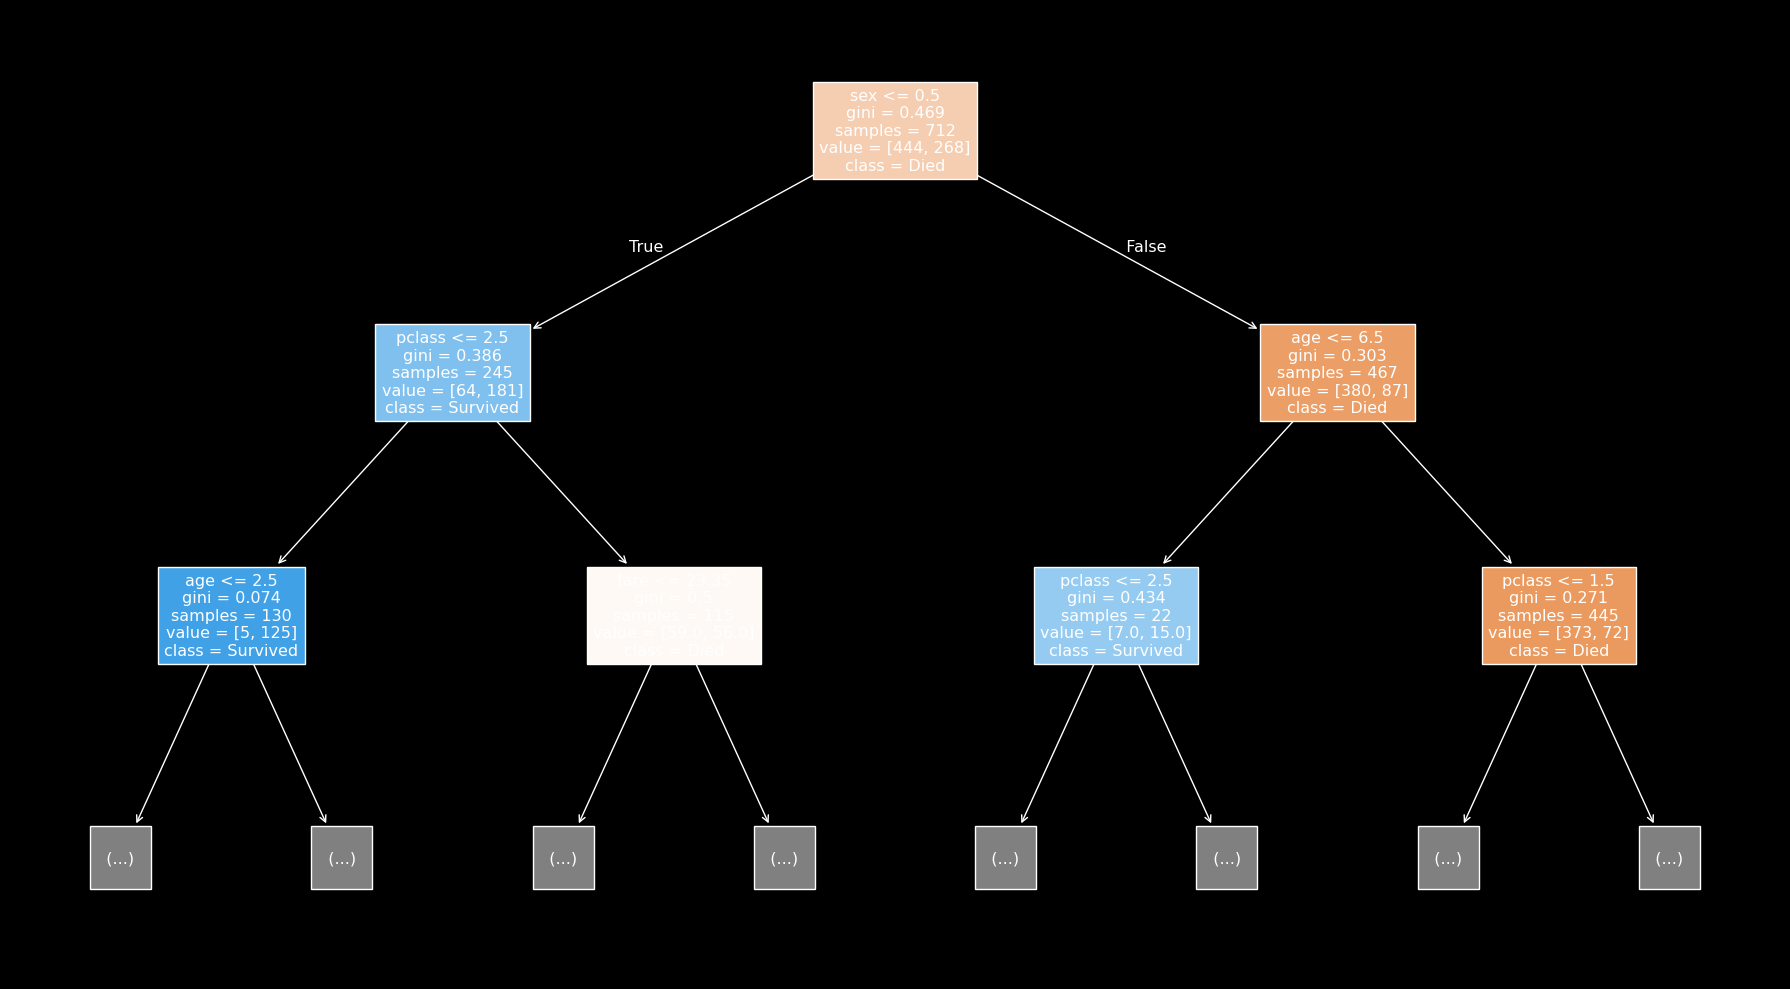

In [32]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=features,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()

## Decission Tree with Pre-pruning


In [34]:
max_depths = [2,3,4,5,6,7,8,9,10]
for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"depth:{depth}, accurracy: {acc}")

depth:2, accurracy: 0.7653631284916201
depth:3, accurracy: 0.7988826815642458
depth:4, accurracy: 0.7988826815642458
depth:5, accurracy: 0.7988826815642458
depth:6, accurracy: 0.8044692737430168
depth:7, accurracy: 0.7988826815642458
depth:8, accurracy: 0.7932960893854749
depth:9, accurracy: 0.7932960893854749
depth:10, accurracy: 0.7988826815642458


In [37]:
min_smaples_splits = [3,5,10,15, 20,25, 30]
for split in min_smaples_splits:
    model = DecisionTreeClassifier(max_depth=6, min_samples_split=split)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"split:{split}, accurracy: {acc}")

split:3, accurracy: 0.8044692737430168
split:5, accurracy: 0.7988826815642458
split:10, accurracy: 0.8100558659217877
split:15, accurracy: 0.8044692737430168
split:20, accurracy: 0.8044692737430168
split:25, accurracy: 0.7988826815642458
split:30, accurracy: 0.7877094972067039


## Decission Tree with Post-Pruning


In [40]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

### Train our model for all ccp alphas


In [41]:
tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    tree.append((model, alpha))

In [42]:
best_acc = 0
best_alpha = 0
for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha
print(best_alpha)
print(best_acc)

0.0015407231242023183
0.8379888268156425


### Now we find best ccp_alpha value to train our model


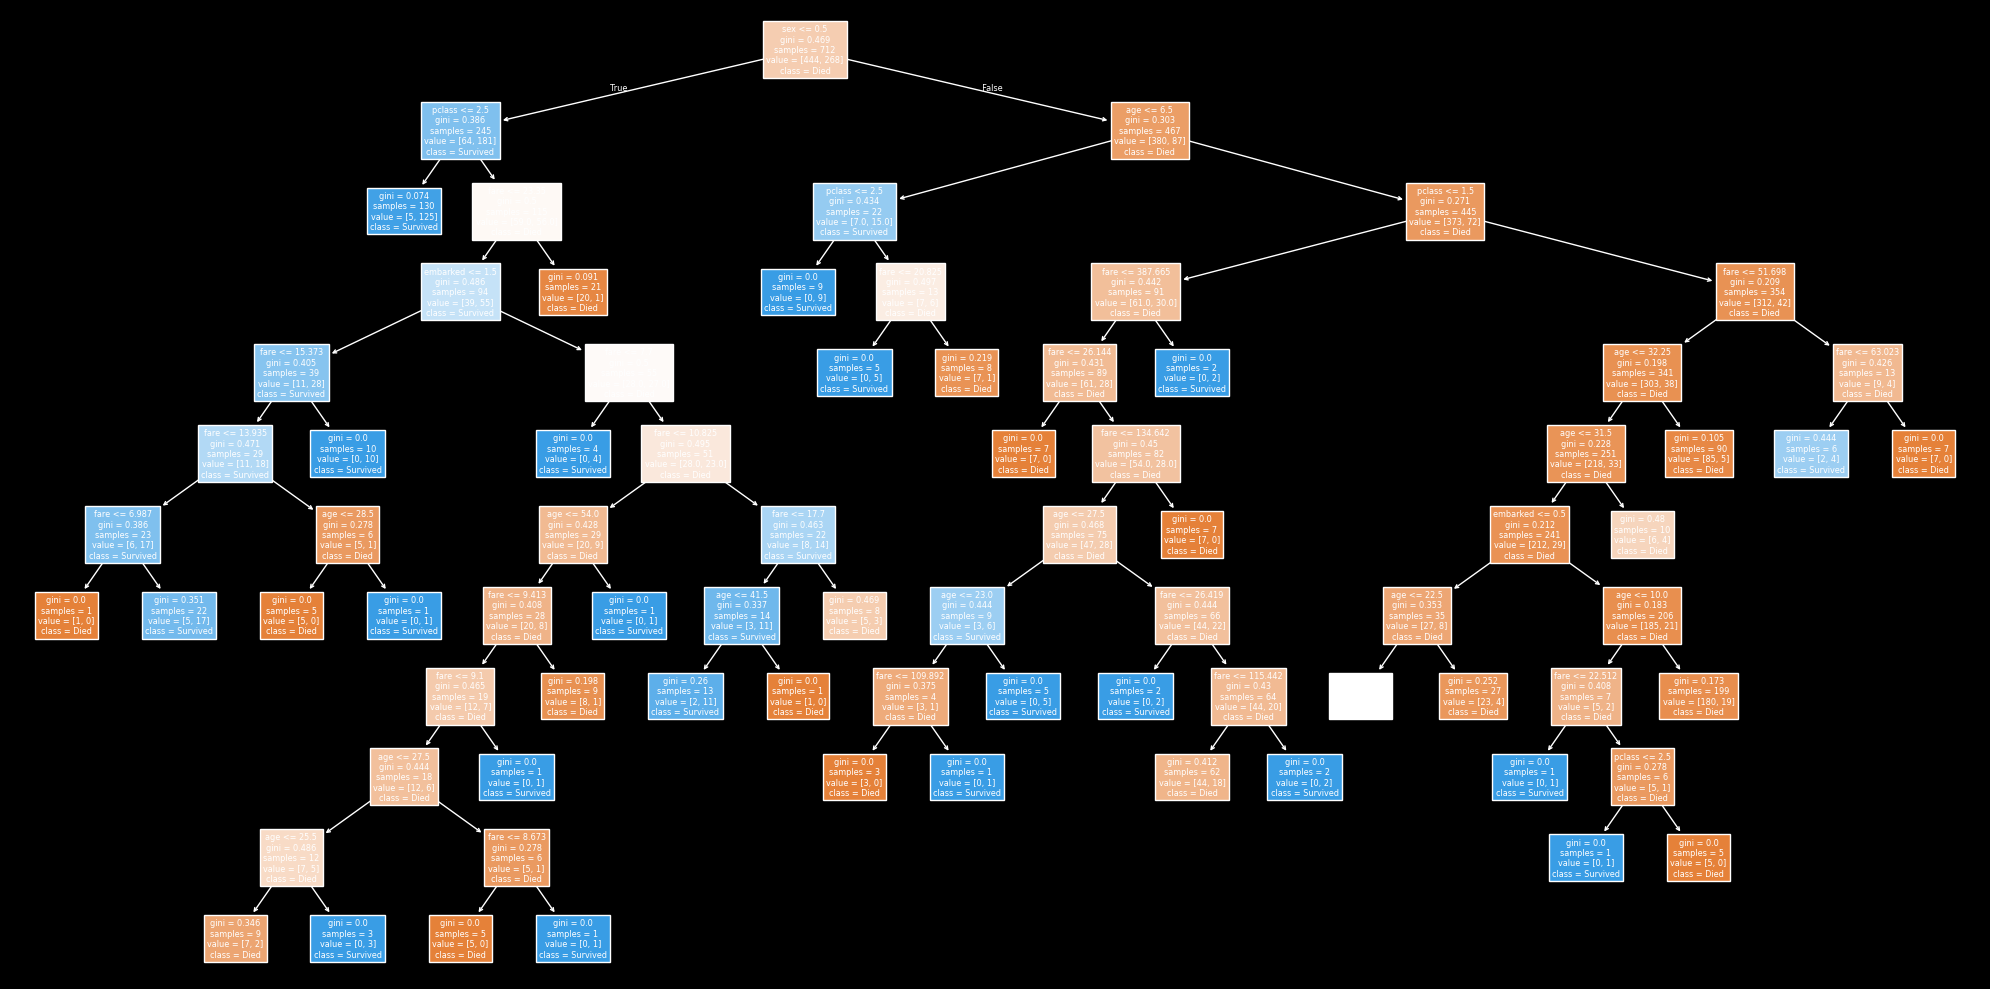

In [43]:
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True
)
plt.tight_layout()
plt.show()

In [44]:
best_model.score(X_test, y_test)

0.8379888268156425